In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_excel("C://Users//Asus//Mahesh_Program//Machine_Learning_Superviced_learniing//HousePrice_Pridication//RealEstate_HousePrice_Dataset_4200.xlsx")

In [3]:
data.head()

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


# Topic :- Data Understanding & Preparation

  Task 7 :- Identify Independent Variables and Dependent Variables

In [4]:
##### --------- Independent Variables 

x = data[[ 'house_id' ,
       'area_sqft' ,
       'bedrooms' ,
       'bathrooms' ,
       'location_score' ,
       'age_years' ,
       'distance_city_km' ,
       'lot_size_sqft' ,
       'has_garage' ,
       'has_pool' ,
       'renovation_years_ago']]

print("Independent Variables : ",x.columns)


##### ------------ Dependent Variables

y = data[['house_price_inr']]

print()

Independent Variables :  Index(['house_id', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score',
       'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage',
       'has_pool', 'renovation_years_ago'],
      dtype='str')



Task 8 :- visualize relationships between features and target variable

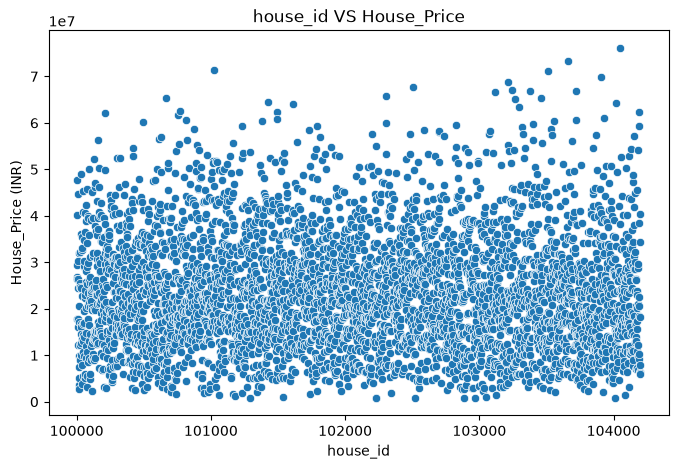

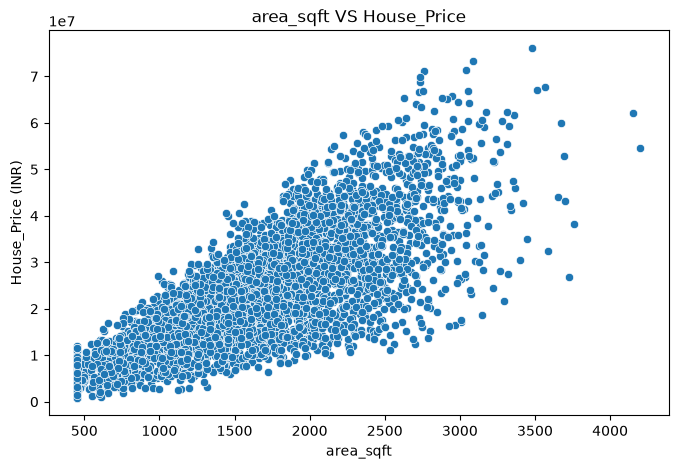

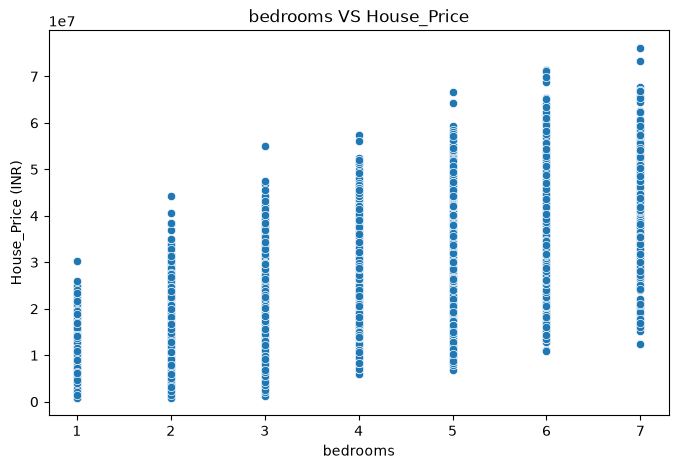

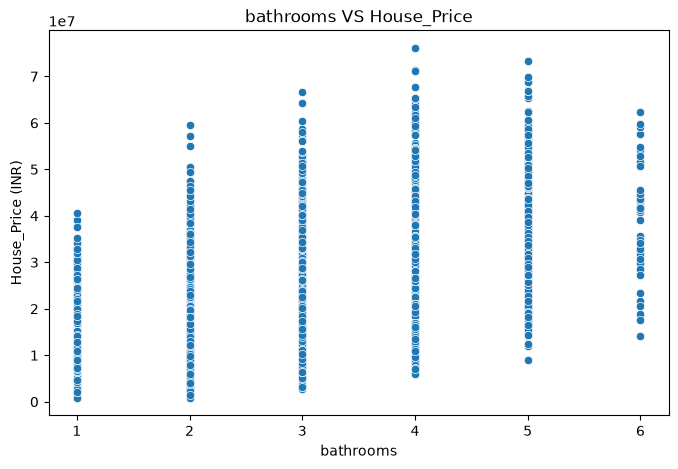

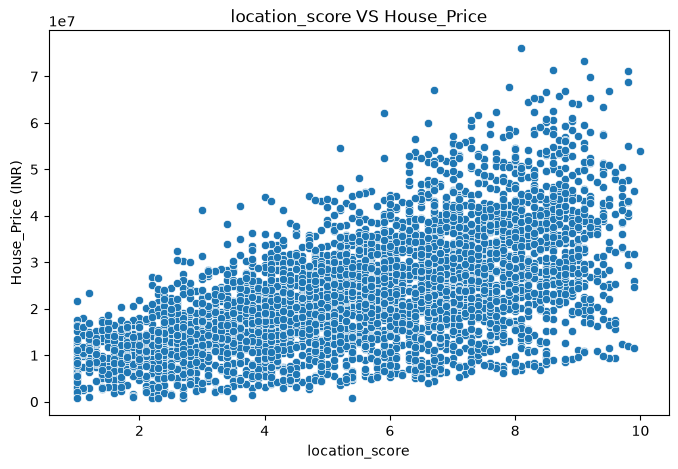

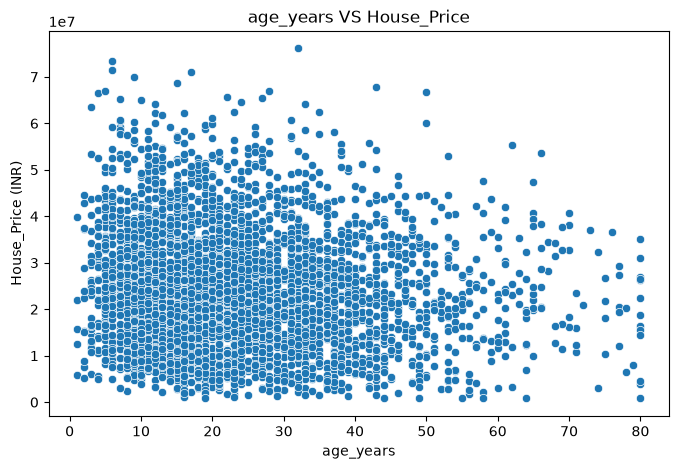

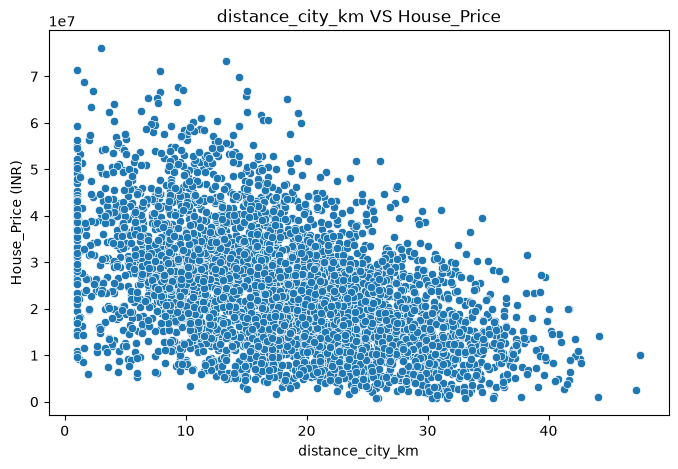

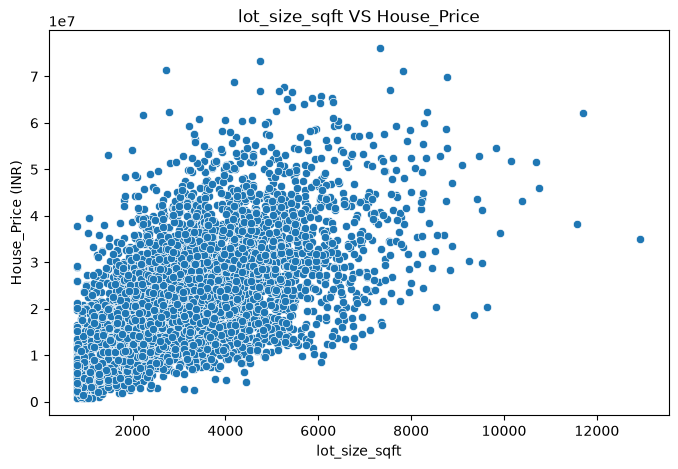

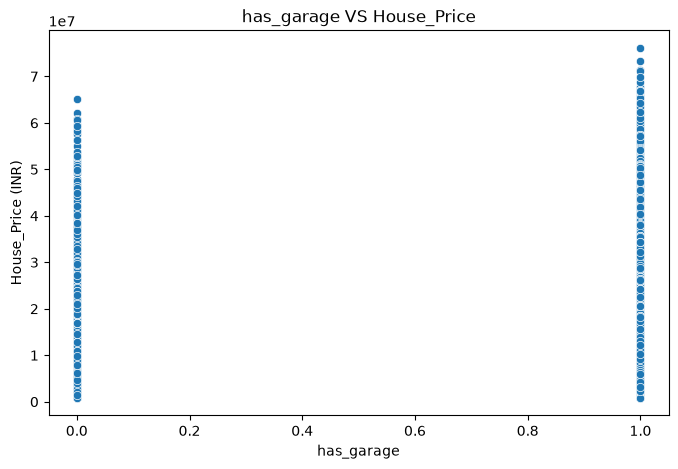

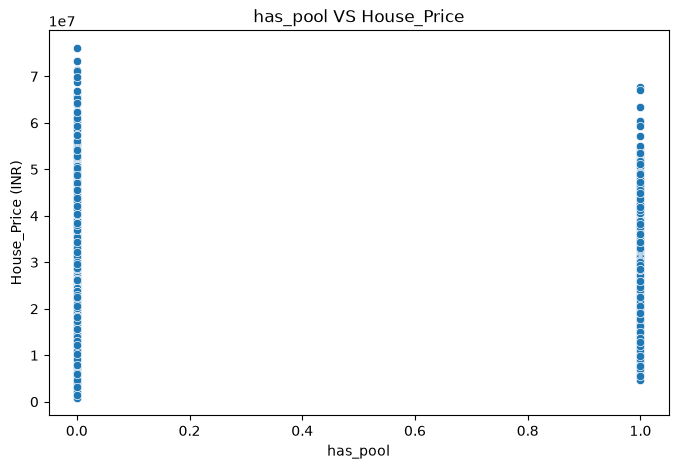

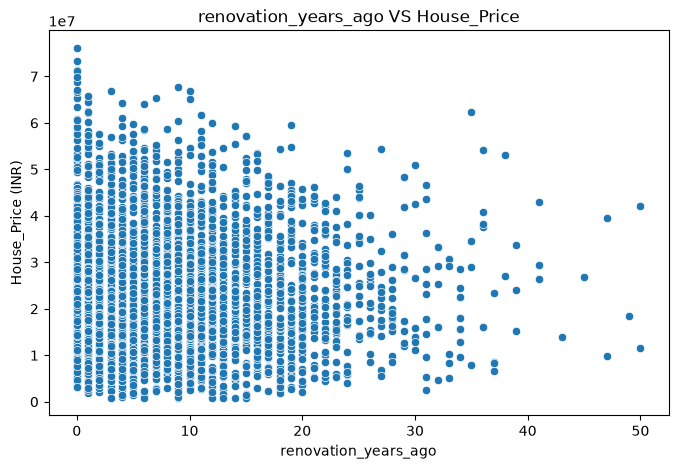

In [5]:
features = x

for feature in features:
    plt.figure(figsize=(8,5))
    sns.scatterplot(data=data , x = feature , y = 'house_price_inr')
    plt.title(f"{feature} VS House_Price")
    plt.xlabel(feature)
    plt.ylabel('House_Price (INR)')
    plt.show()

Task 9 :- Split the dataset into training and testing sets

In [6]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(
    x , y,
    test_size = 0.2 , 
    random_state = 42
)

# Check
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(3360, 11)
(840, 11)
(3360, 1)
(840, 1)


#  📈 Topic : Simple Linear Regression

Task 10 : simple linear ligression

In [7]:
from sklearn.linear_model import LinearRegression

x_simple = data[['area_sqft']]
y_simple = data['house_price_inr']

x_train , x_test , y_train , y_test  = train_test_split(
    x_simple , y_simple ,
    test_size = 0.2 ,
    random_state = 42
)

model = LinearRegression()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)
print("Simple Linear Regression trained successfully.")

Simple Linear Regression trained successfully.


Task 11 : Regression line and interpret the slope and intercept

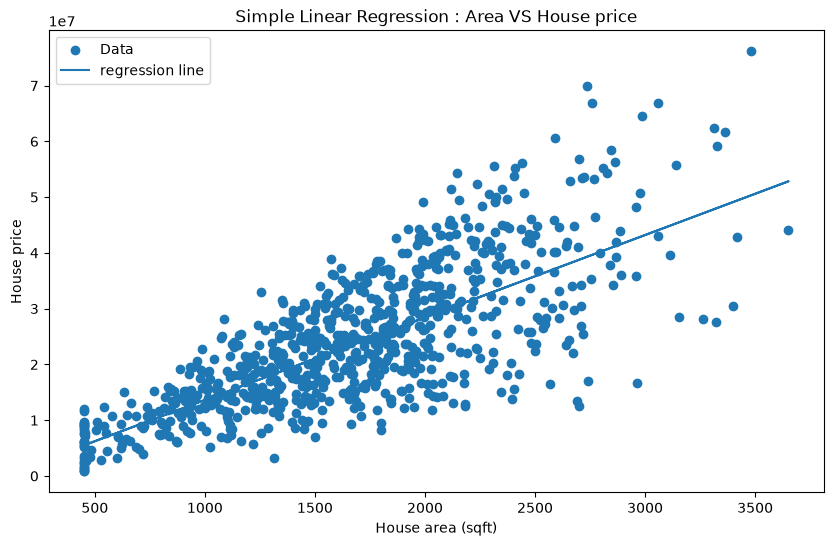

slope : 14788.306111307538
intercept : -1163519.1764186062

 equation : house price = -1163519.18 +  (14788.31 * area)


In [8]:
plt.figure(figsize=(10,6))
plt.scatter(x_test['area_sqft'] , y_test , label='Data')
plt.plot(
    x_test['area_sqft'],
    y_pred,
    label='regression line'
)
plt.xlabel('House area (sqft)')
plt.ylabel('House price')
plt.title('Simple Linear Regression : Area VS House price')
plt.legend()
plt.show()



# Slop and Intercept
slope = model.coef_[0]
intercept = model.intercept_
print('slope :',slope)
print('intercept :',intercept)
print(f"\n equation : house price = {intercept:.2f} + "f" ({slope:.2f} * area)")


Task 12 : Linear Regression Assumptions plots and observations.

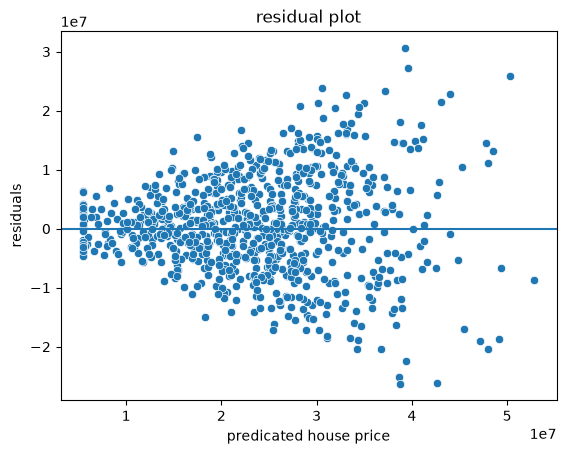

In [9]:
residuals = y_test - y_pred
sns.scatterplot(x = y_pred , y = residuals)
plt.axhline(y = 0 )
plt.xlabel('predicated house price')
plt.ylabel('residuals')
plt.title('residual plot')
plt.show()

# 📊 Topic : Model Evaluation Metrics

Task 13 :- Evaluate the Simple Linear Regression model using :
Mean Squared Error (MSE) ,
Mean Absolute Error (MAE) ,
Root Mean Squared Error (RMSE) ,
R² Score ,
Adjusted R² Score


In [10]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test , y_pred)
print("mse :",mse)

# MAE
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error (y_test , y_pred)
print("mae :",mae)

# RMSE
rmse = np.sqrt(mse)
print("rmse : ",rmse)

# R2 Score
from sklearn.metrics import r2_score
r2 = r2_score(y_test , y_pred)
print("r2_score : ",r2)

# Adjusted R² Score
n = len(y_test)
p = x_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
print("adjusted_r2_score :",adjusted_r2)

mse : 66989260021849.46
mae : 6294593.696131912
rmse :  8184696.6969979685
r2_score :  0.562519958799158
adjusted_r2_score : 0.5619979062440257


# 📉 Topic : Multiple Linear Regression


Task 15 : Multiple Linear Regression using all relevant features.

In [11]:
# Independent variables
x = data[['area_sqft','age_years']]
# dependent variable
y  = data['house_price_inr']

# Train-test split
from sklearn.model_selection import train_test_split
X_train , X_test , Y_train , Y_test = train_test_split(
    x , y ,
    test_size = 0.2 ,
    random_state = 42
)

# create model
from sklearn.linear_model import LinearRegression
model = LinearRegression()

# Train model
model.fit(X_train , Y_train)

# pridiction
Y_pred = model.predict(X_test)

# show shape
print("X_train : ",X_train.shape)
print("X_test : ",X_test.shape)
print("Y_train : ",Y_train.shape)
print("Y_test : ",Y_test.shape)

print("\nMultiple Linear Regression trained successfully.")

X_train :  (3360, 2)
X_test :  (840, 2)
Y_train :  (3360,)
Y_test :  (840,)

Multiple Linear Regression trained successfully.


Task 16 : Compare its performance with Simple Linear Regression.

In [13]:
# MSE
from sklearn.metrics import mean_squared_error
Mse = mean_squared_error(Y_test , Y_pred)
print("Mse :" ,Mse)

# MAE
from sklearn.metrics import mean_absolute_error
Mae = mean_absolute_error(Y_test , Y_pred)
print("Mae : ",Mae)

# RMSE 
Rmse = np.sqrt(Mse)
print("Rmse : ",Rmse)

# R2_score
from sklearn.metrics import r2_score
R2 = r2_score(Y_test , Y_pred)
print("R2_score : ", R2)

# Adjusted R2 score
n = len(Y_test)
p = X_test.shape[1]
Adjusted_R2 = 1 - ((1 - R2) * (n -1) / (n - p - 1))
print("Adjusted_R2_score : ", Adjusted_R2)

Mse : 66189501325453.875
Mae :  6237589.13566738
Rmse :  8135693.045183912
R2_score :  0.5677428626995108
Adjusted_R2_score :  0.5667099902089481


Compare models 

In [15]:
comparison = {
    "matric" : ["MSE","MAE","RMSE","R2","adjusted_R2_score"],
    "Simple Linear Regression" : [
        mse , mae , rmse , r2 , adjusted_r2
    ],
    "Muliple Linear Regression" : [
        Mse , Mae , Rmse , R2 , Adjusted_R2
    ]
}
comparison_df = pd.DataFrame(comparison)
print(comparison_df)

              matric  Simple Linear Regression  Muliple Linear Regression
0                MSE              6.698926e+13               6.618950e+13
1                MAE              6.294594e+06               6.237589e+06
2               RMSE              8.184697e+06               8.135693e+06
3                 R2              5.625200e-01               5.677429e-01
4  adjusted_R2_score              5.619979e-01               5.667100e-01


# 🔁 Topic :  Polynomial Regression

Task 18 : Polynomial Regression (degree 2 or 3)

In [16]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
# features & target
x_fe = data[['area_sqft']]
y_fe = data['house_price_inr']

# train split
x_feu_train , x_feu_test , y_feu_train , y_feu_test = train_test_split(
    x_fe ,y_fe ,
    test_size = 0.2 ,
    random_state = 42
)

# Polynomial features - Degree 2
poly = PolynomialFeatures(degree=2)

x_train_poly = poly.fit_transform(x_feu_train)
x_test_poly = poly.transform(x_feu_test)

# model
poly_model = LinearRegression()
poly_model.fit(x_train_poly,y_feu_train)

# pridiction
y_pred_poly = poly_model.predict(x_test_poly)
print("Polynomial Regression Degree 2 trained successfully.")


###########################################################################################
                              # Numarical Comparison #
###########################################################################################
from sklearn.metrics import mean_squared_error

r2_poly = r2_score(y_feu_test , y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_feu_test , y_pred_poly))
print("Polynomial R²:", r2_poly)
print("Polynomial RMSE:", rmse_poly)
print("\nSimple Linear R²:", r2_score(y_test,y_pred))
print("Simple Linear RMSE:", np.sqrt(mean_squared_error(y_test,y_pred)))

Polynomial Regression Degree 2 trained successfully.
Polynomial R²: 0.5626917978136464
Polynomial RMSE: 8183089.094113444

Simple Linear R²: 0.562519958799158
Simple Linear RMSE: 8184696.6969979685


Task 19 : Compare linear vs polynomial regression visually and numerically.

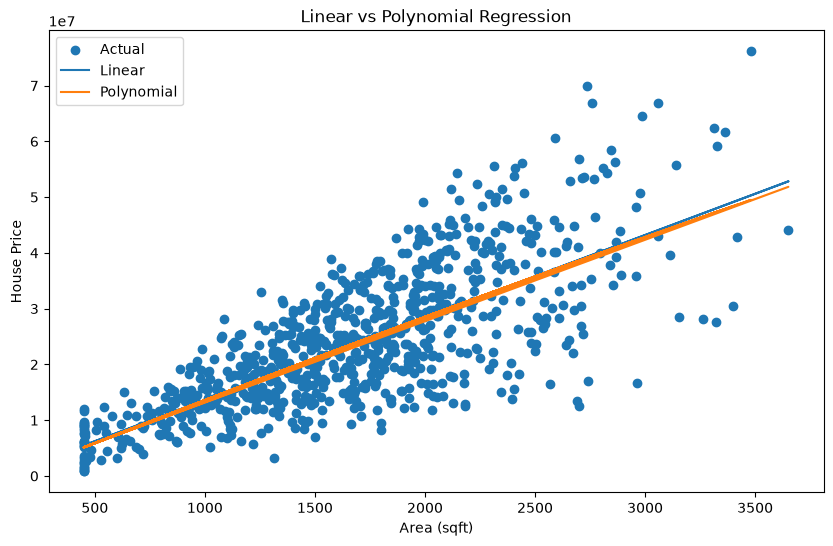

In [17]:
plt.figure(figsize=(10, 6))

plt.scatter(x_feu_test, y_feu_test, label="Actual")
plt.plot(x_feu_test, y_pred, label="Linear")
plt.plot(x_feu_test, y_pred_poly, label="Polynomial")

plt.xlabel("Area (sqft)")
plt.ylabel("House Price")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.show()

Task 20 : Identify signs of overfitting or underfitting.


In [18]:
for degree in [1, 2, 3, 4, 5]:
    poly = PolynomialFeatures(degree=degree)
    
    X_train_poly = poly.fit_transform(x_feu_train)
    X_test_poly = poly.transform(x_feu_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_feu_train)

print(
    degree,
    "Train R²:", model.score(X_train_poly, y_feu_train),
    "Test R²:", model.score(X_test_poly, y_feu_test)
    )

5 Train R²: 0.5084888502299405 Test R²: 0.5023012520664245


# ⚙️ Topic : Gradient Descent Optimization


Task :  Gradient Descent conceptually.

In [19]:
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

grd_features = ['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'age_years']

X_grd = data[grd_features].values
y_grd = data['house_price_inr'].values

X_train_grd, X_test_grd, y_train_grd, y_test_grd = train_test_split(
    X_grd, y_grd, test_size=0.20, random_state=42
)

scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train_grd)
X_test_scaled = scaler_X.transform(X_test_grd)

y_mean = y_train_grd.mean()
y_std = y_train_grd.std()

y_train_scaled = (y_train_grd - y_mean) / y_std
y_test_scaled = (y_test_grd - y_mean) / y_std


Task : Batch Gradient Descent from scratch.


In [20]:
def batch_gradient_descent(X,y,learning_rate=0.01,epochs=1000):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0
    losses = []
    for epoch in range(epochs):
        predictions = np.dot(X, weights) + bias
        errors = predictions - y
        dw = (2 / n_samples) * np.dot(X.T,errors) 
        db = (2 / n_samples) * np.sum(errors)
        weights -= learning_rate * dw
        bias -= learning_rate * db
        loss = np.mean(errors ** 2)
        losses.append(loss)
    return weights, bias, losses

Task : Trainbatch GD



In [21]:
import time
start_time = time.time()
batch_weights, batch_bias, batch_losses = batch_gradient_descent(
    X_train_scaled,
    y_train_scaled,
    learning_rate=0.01,
    epochs=1000)
batch_time = time.time() - start_time
batch_pred_scaled = (np.dot(X_test_scaled, batch_weights)+ batch_bias)
batch_pred = (batch_pred_scaled * y_std+ y_mean)
print("Batch GD Training Time:", batch_time)

Batch GD Training Time: 0.04435157775878906


Task : Implement Stochastic Gradient Descent From Scratch


In [22]:
def stochastic_gradient_descent(X,y,learning_rate=0.01,epochs=50,random_state=42): 
    rng = np.random.default_rng(random_state) 
    n_samples, n_features = X.shape 
    weights = np.zeros(n_features)
    bias = 0 
    losses = []
    for epoch in range(epochs):      
        indices = rng.permutation(n_samples)  
        for i in indices: 
            xi = X[i]
            yi = y[i]
            prediction = np.dot(xi,weights) + bias
            error = prediction - yi 
            dw = 2 * error * xi
            db = 2 * error
            weights -= learning_rate * dw
            bias -= learning_rate * db
        predictions = np.dot(
            X,
            weights
        ) + bias
        
        loss = np.mean(
            (predictions - y) ** 2
        )
        
        losses.append(loss)
    
    return weights, bias, losses

Task : Train SGD

In [23]:
start_time = time.time()
sgd_weights, sgd_bias, sgd_losses = stochastic_gradient_descent(
    X_train_scaled,
    y_train_scaled,
    learning_rate=0.001,
    epochs=50)
sgd_time = time.time() - start_time
sgd_pred_scaled = (np.dot(X_test_scaled,sgd_weights) + sgd_bias)
sgd_pred = (sgd_pred_scaled * y_std+ y_mean)
print("SGD Training Time:", sgd_time)

SGD Training Time: 0.7062623500823975


Task : Mini-Batch Gradient Descent

In [24]:
def mini_batch_gradient_descent(
    X,
    y,
    learning_rate=0.01,
    epochs=100,
    batch_size=32,
    random_state=42):
    rng = np.random.default_rng(random_state)    
    n_samples, n_features = X.shape    
    weights = np.zeros(n_features)
    bias = 0
    losses = []  
    for epoch in range(epochs):  
        indices = rng.permutation(n_samples)  
        X_shuffled = X[indices]
        y_shuffled = y[indices] 
        for start in range(0,n_samples,batch_size):    
            end = start + batch_size   
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end] 
            predictions = (np.dot(X_batch,weights) + bias)
            errors = predictions - y_batch 
            dw = (2 / len(X_batch)) * np.dot(X_batch.T,errors)
            db = (2 / len(X_batch) ) * np.sum(errors)
            weights -= learning_rate * dw
            bias -= learning_rate * db
        predictions = (np.dot(X, weights) + bias )
        loss = np.mean((predictions - y) ** 2 )
        losses.append(loss)
    return weights, bias, losses

Train mini-batch GD

In [25]:
start_time = time.time()
mini_weights, mini_bias, mini_losses = mini_batch_gradient_descent(
    X_train_scaled,
    y_train_scaled,
    learning_rate=0.01,
    epochs=100,
    batch_size=32)
mini_time = time.time() - start_time
mini_pred_scaled = (np.dot(X_test_scaled,mini_weights) + mini_bias)
mini_pred = (mini_pred_scaled * y_std+ y_mean)
print("Mini-Batch GD Training Time:", mini_time)

Mini-Batch GD Training Time: 0.12154126167297363


Compare Convergence Behavior and Training Time

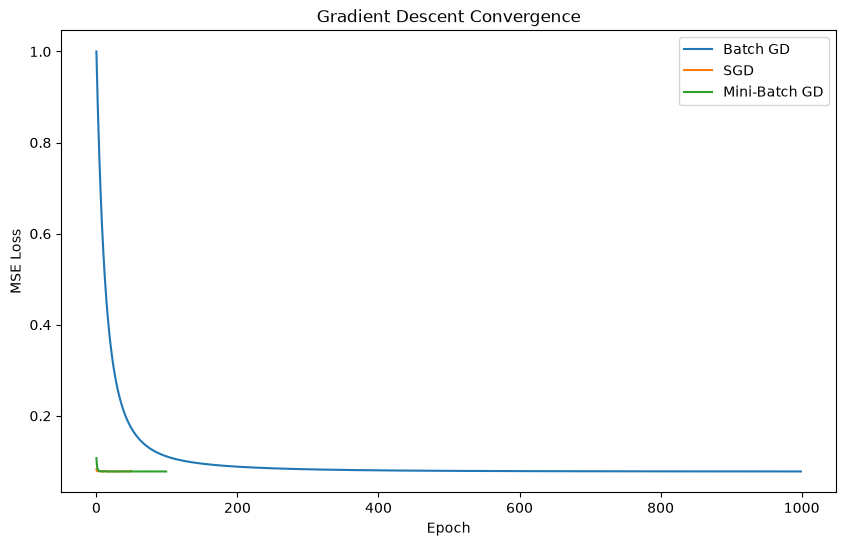

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(batch_losses,label='Batch GD')
plt.plot(sgd_losses,label='SGD')
plt.plot(mini_losses,label='Mini-Batch GD')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Gradient Descent Convergence')
plt.legend()
plt.show()

In [27]:
# Training Time Comparison #
gd_time_comparison = pd.DataFrame({'Method': ['Batch GD','SGD','Mini-Batch GD'],
    'Training Time (seconds)': [batch_time,sgd_time,mini_time]})
display(gd_time_comparison)

,Method,Training Time (seconds)
0,Batch GD,0.044352
1,SGD,0.706262
2,Mini-Batch GD,0.121541


In [28]:
# Performance Comparison #
gd_models = {
    'Batch GD': batch_pred,
    'SGD': sgd_pred,
    'Mini-Batch GD': mini_pred}
gd_results = []
for name, predictions in gd_models.items():   
    mse = mean_squared_error(y_test_grd,predictions) 
    rmse = np.sqrt(mse) 
    mae = mean_absolute_error(y_test_grd,predictions)
    r2 = r2_score(y_test_grd,predictions)
    gd_results.append([name, mse,mae, rmse, r2])
gd_comparison = pd.DataFrame(gd_results,
    columns=['Method','MSE','MAE','RMSE','R²' ])
display(gd_comparison)

,Method,MSE,MAE,RMSE,R²
0,Batch GD,1.288829e+13,2.643369e+06,3.590027e+06,0.915832
1,SGD,1.333724e+13,2.659510e+06,3.652018e+06,0.912900
2,Mini-Batch GD,1.290690e+13,2.642581e+06,3.592618e+06,0.915710


# 📐 Topic : Bias–Variance & Model Diagnostics


Task 26 : Analyze bias and variance across:
Simple Linear Regression ,
Multiple Linear Regression ,
Polynomial Regression


In [29]:
# ------------------------------------------------
# 1. SIMPLE LINEAR REGRESSION
# ------------------------------------------------
simple_model = LinearRegression()
simple_model.fit(x_train, y_train)
simple_train_pred = simple_model.predict(x_train)
simple_test_pred = simple_model.predict(x_test)
# ------------------------------------------------
# 2. MULTIPLE LINEAR REGRESSION
# ------------------------------------------------
multiple_model = LinearRegression()
multiple_model.fit(X_train, Y_train)
multiple_train_pred = multiple_model.predict(X_train)
multiple_test_pred = multiple_model.predict(X_test)
# ------------------------------------------------
# 3. POLYNOMIAL REGRESSION
# ------------------------------------------------
poly_train_pred = poly_model.predict(x_train_poly)
poly_test_pred = poly_model.predict(x_test_poly)
# ------------------------------------------------
# 4. CALCULATE TRAIN & TEST MSE
# ------------------------------------------------
models_data = [
    (
        "Simple Linear Regression",
        y_train,
        simple_train_pred,
        y_test,
        simple_test_pred
    ),
    (
        "Multiple Linear Regression",
        Y_train,
        multiple_train_pred,
        Y_test,
        multiple_test_pred
    ),
    (
        "Polynomial Regression",
        y_feu_train,
        poly_train_pred,
        y_feu_test,
        poly_test_pred
    )
]


models_bias_variance = []


for name, y_train_actual, train_pred, y_test_actual, test_pred in models_data:

    train_mse = mean_squared_error(
        y_train_actual,
        train_pred
    )

    test_mse = mean_squared_error(
        y_test_actual,
        test_pred
    )

    # Practical bias proxy
    bias = train_mse

    # Train-Test error gap as variance proxy
    variance = abs(test_mse - train_mse)

    models_bias_variance.append([
        name,
        train_mse,
        test_mse,
        bias,
        variance
    ])


# ------------------------------------------------
# 5. FINAL COMPARISON TABLE
# ------------------------------------------------

bias_variance_df = pd.DataFrame(
    models_bias_variance,
    columns=[
        "Model",
        "Train MSE",
        "Test MSE",
        "Bias",
        "Variance"
    ]
)

print("Bias-Variance Analysis")
print("=" * 80)
print(bias_variance_df)

Bias-Variance Analysis
                        Model     Train MSE      Test MSE          Bias  \
0    Simple Linear Regression  6.568175e+13  6.698926e+13  6.568175e+13   
1  Multiple Linear Regression  6.496312e+13  6.618950e+13  6.496312e+13   
2       Polynomial Regression  6.565719e+13  6.696295e+13  6.565719e+13   

       Variance  
0  1.307506e+12  
1  1.226382e+12  
2  1.305756e+12  


Task 28 : Identify which model best balances bias and variance


In [30]:
results = []

for degree in [1, 2, 3, 4, 5]:

    # Create polynomial features
    poly_temp = PolynomialFeatures(degree=degree)

    X_train_temp = poly_temp.fit_transform(x_feu_train)
    X_test_temp = poly_temp.transform(x_feu_test)

    # Create model
    model_temp = LinearRegression()

    # Train model
    model_temp.fit(X_train_temp, y_feu_train)

    # Predictions
    train_pred_temp = model_temp.predict(X_train_temp)
    test_pred_temp = model_temp.predict(X_test_temp)

    # MSE
    train_mse_temp = mean_squared_error(
        y_feu_train,
        train_pred_temp
    )

    test_mse_temp = mean_squared_error(
        y_feu_test,
        test_pred_temp
    )

    # Bias-Variance gap
    variance_gap_temp = abs(
        test_mse_temp - train_mse_temp
    )

    results.append([
        degree,
        train_mse_temp,
        test_mse_temp,
        variance_gap_temp
    ])


# Create DataFrame
q28_result = pd.DataFrame(
    results,
    columns=[
        "Polynomial Degree",
        "Train MSE",
        "Test MSE",
        "Variance Gap"
    ]
)

print(q28_result)


# Model with lowest Test MSE
best_model_q28 = q28_result.loc[
    q28_result["Test MSE"].idxmin()
]

print("\nBest Balanced Model:")
print(best_model_q28)

   Polynomial Degree     Train MSE      Test MSE  Variance Gap
0                  1  6.568175e+13  6.698926e+13  1.307506e+12
1                  2  6.565719e+13  6.696295e+13  1.305756e+12
2                  3  6.615097e+13  6.734456e+13  1.193587e+12
3                  4  6.927247e+13  7.017407e+13  9.016050e+11
4                  5  7.548253e+13  7.621027e+13  7.277345e+11

Best Balanced Model:
Polynomial Degree    2.000000e+00
Train MSE            6.565719e+13
Test MSE             6.696295e+13
Variance Gap         1.305756e+12
Name: 1, dtype: float64


# 🧾 Topic : Final Analysis & Reporting


In [ ]:
final_results = bias_variance_df.copy()
final_results.to_csv("model_evaluation_results.csv",index=False)
print("Model evaluation results saved successfully.")